In [ ]:
# Notebook bootstrap for src-layout imports
import sys
from pathlib import Path

_ROOT = Path.cwd()
_SRC = _ROOT / "src"
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

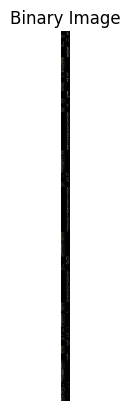

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image_path = "data/35/panorama0.png"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY)
image = image * (binary > 0)[..., None].astype(image.dtype)
# plt.imshow(image, cmap='gray')
# plt.title('Binary Image')
# plt.axis('off')
# plt.show()

In [6]:
print(image.shape)

(59079, 1427, 3)


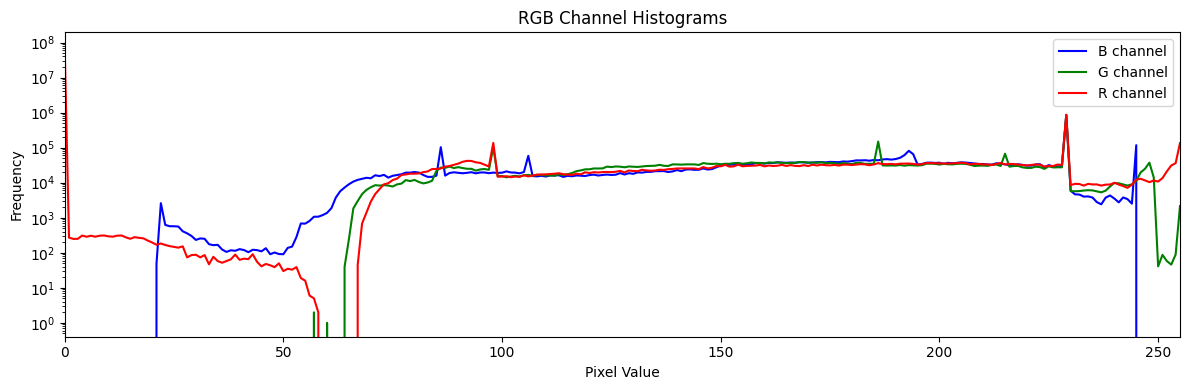

In [2]:
colors = ("b", "g", "r")
plt.figure(figsize=(12, 4))
for i, color in enumerate(colors):
    hist_channel = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist_channel, color=color, label=f"{color.upper()} channel")
    plt.xlim([0, 255])
plt.xlabel("Pixel Value")
plt.yscale("log")
plt.ylabel("Frequency")
plt.title("RGB Channel Histograms")
plt.legend()
plt.tight_layout()
plt.show()

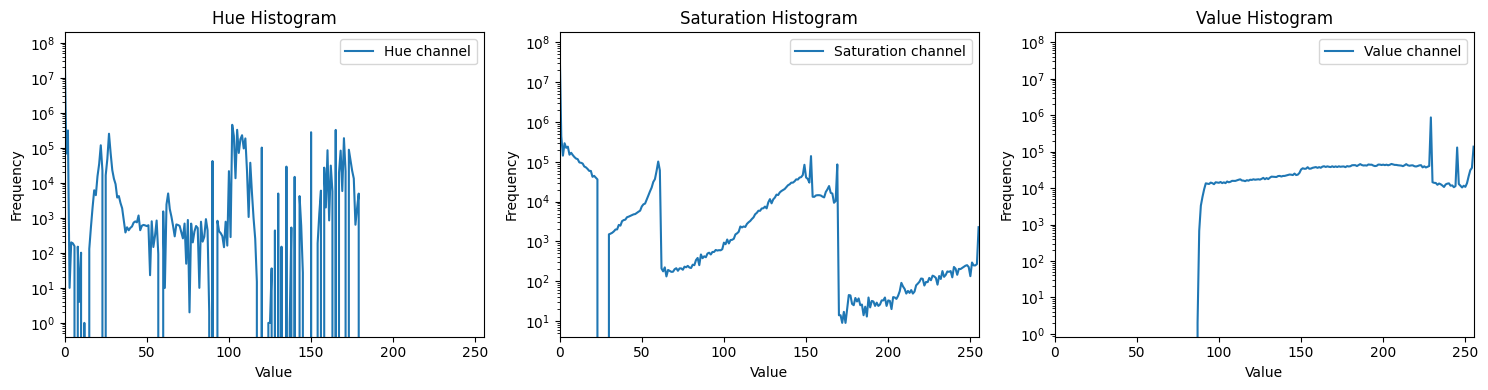

In [ ]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
channels = ["Hue", "Saturation", "Value"]
plt.figure(figsize=(15, 4))
for idx, channel in enumerate(channels):
    hist_hsv = cv2.calcHist([hsv], [idx], None, [256], [0, 256])
    plt.subplot(1, 3, idx + 1)
    plt.plot(hist_hsv, label=f"{channel} channel")
    plt.xlim([0, 255])
    plt.yscale("log")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"{channel} Histogram")
    plt.legend()
plt.tight_layout()
plt.show()

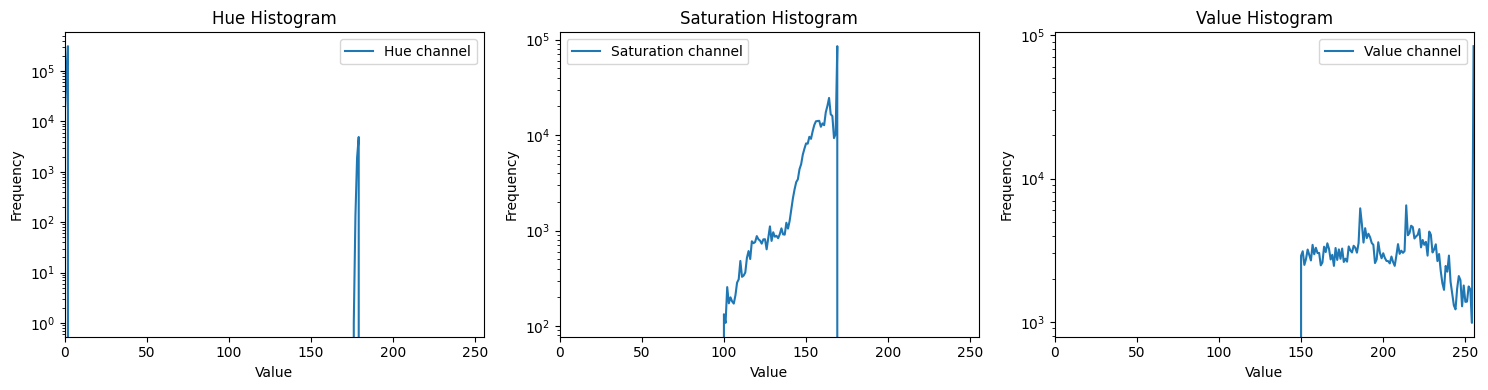

In [3]:
# Apply a mask to ignore pixels with low saturation (S < 25) in subsequent histograms
sat_mask = (((hsv[..., 0] < 10) | (hsv[..., 0] > 160)) & (hsv[..., 1] > 25)).astype(np.uint8) * 255

# Ensure calcHist uses the saturation mask by default
_orig_calcHist = cv2.calcHist


def _calcHist_masked(images, channels, mask, histSize, ranges):
    use_mask = sat_mask if mask is None else (mask & sat_mask)
    return _orig_calcHist(images, channels, use_mask, histSize, ranges)


cv2.calcHist = _calcHist_masked

channels = ["Hue", "Saturation", "Value"]
plt.figure(figsize=(15, 4))
for idx, channel in enumerate(channels):
    hist_hsv = cv2.calcHist([hsv], [idx], None, [256], [0, 256])
    plt.subplot(1, 3, idx + 1)
    plt.plot(hist_hsv, label=f"{channel} channel")
    plt.xlim([0, 255])
    plt.yscale("log")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"{channel} Histogram")
    plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Compute Hue histogram (masked by saturation via patched cv2.calcHist)
hist_hue = cv2.calcHist([hsv], [0], None, [256], [0, 256]).ravel()

# Find non-zero intervals
nz = np.flatnonzero(hist_hue > 0)
intervals = []
if nz.size:
    breaks = np.where(np.diff(nz) > 1)[0]
    starts = np.insert(nz[breaks + 1], 0, nz[0])
    ends = np.append(nz[breaks], nz[-1])
    intervals = list(zip(starts.tolist(), ends.tolist(), strict=False))

print(intervals)

[(0, 2), (15, 23), (25, 41), (43, 43), (61, 75), (102, 105), (176, 179)]


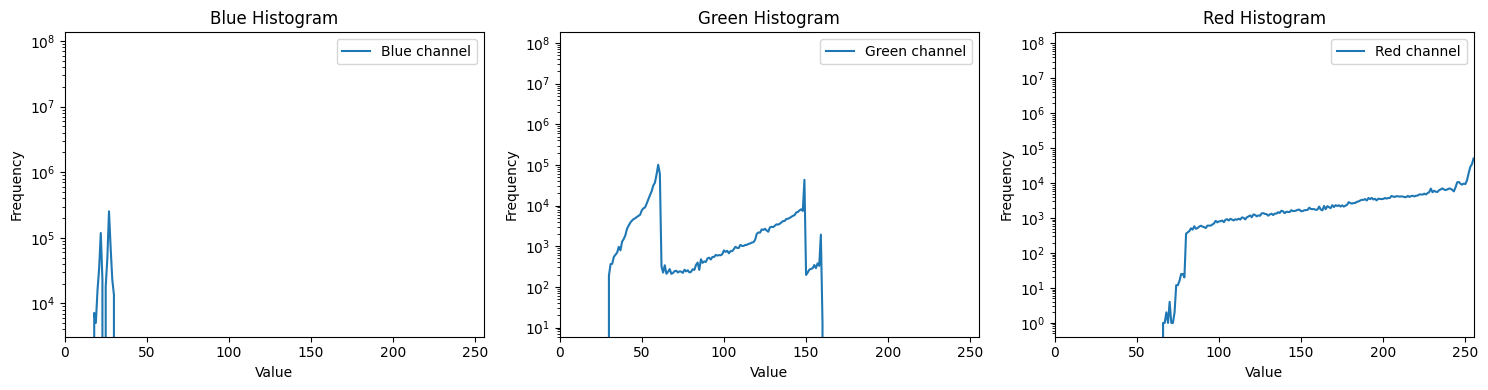

In [5]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_yellow = np.array([18, 26, 0])
upper_yellow = np.array([30, 180, 255])
mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
hsv = hsv * (mask > 0)[..., None].astype(hsv.dtype)

channels = ["Blue", "Green", "Red"]
plt.figure(figsize=(15, 4))
for idx, channel in enumerate(channels):
    hist_hsv = cv2.calcHist([hsv], [idx], None, [256], [0, 256])
    plt.subplot(1, 3, idx + 1)
    plt.plot(hist_hsv, label=f"{channel} channel")
    plt.xlim([0, 255])
    plt.yscale("log")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"{channel} Histogram")
    plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import paddle

gpu_available = paddle.device.is_compiled_with_cuda()
print("GPU available:", gpu_available)

GPU available: True


In [3]:
from openvino.runtime import Core

ie = Core()
print("Available devices:", ie.available_devices)

C:\Users\mooth\AppData\Roaming\Python\Python311\site-packages\openvino\runtime\__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


Available devices: ['CPU', 'GPU', 'NPU']


In [4]:
import platform

print(platform.architecture()[0])
print(platform.machine())

64bit
AMD64


In [2]:
from cnocr import CnOcr

img_fp = r"D:\Game\playground\SBAT_v0.2\data\42\images_to_stitch\0006.png"
ocr = CnOcr()  # 所有参数都使用默认值
out = ocr.ocr(img_fp)

print(out)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "d:\anaconda\Lib\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\mooth\AppData\Local\Temp\ipykernel_22388\3199493103.py", line 1, in <module>
    from cnocr import CnOcr
  File "C:\Users\mooth\AppData\Roaming\Python\Python311\site-packages\cnocr\__init__.py", line 20, in <module>
    from cnstd.consts import AVAILABLE_MODELS as DET_AVAILABLE_MODELS
  File "C:\Users\mooth\AppData\Roaming\Python\Python311\site-packages\cnstd\__init__.py", line 20, in <module>
    from .detector import Detector
  File "C:\Users\mooth\AppData\Roaming\Python\Python311\site-packages\cnstd\detector.py", line 31, in <module>
    from .consts import MODEL_VERSION, AVAILABLE_MODELS, DOWNLOAD_SOURCE
  File "C:\Users\mooth\AppData\Roaming\Python\Python311\site-packages\cnstd\consts.py", line 27, in <module>
    from torchvision.models import (
  File "C:\Users\mooth\AppData\Roami

In [1]:
import paddle

print(paddle.utils.run_check())
gpu_available = paddle.device.is_compiled_with_cuda()
print("GPU available:", gpu_available)

Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 CPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.
None
GPU available: False
